In [21]:
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

carpeta_salida_figuras = Path("../Outputs/Figures")
carpeta_salida_figuras.mkdir(parents=True, exist_ok=True)

carpeta_salida_tablas = Path("../Outputs/Tables")
carpeta_salida_tablas.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None) # Maximiza la cantidad de columnas que muestra el dataframe
pd.set_option("display.max_rows", None) # Maximiza la cantidad de filas que muestra el dataframe
pd.set_option("display.max_colwidth", None) # Maximiza la cantidad de información que muestran las celdas del dataframe

df = pd.read_csv(r"../Data/processed/Caracteristicas y composicion del hogar - Filtrado.csv"
                 , sep=",") 
df.head(5)

,Es_Jefe_de_hogar,Edad,Estado_civil,Autorreconocimiento_etnico,Satisfaccion_vida,Satisfaccion_ingreso,Satisfaccion_salud,Satisfaccion_seguridad,Satisfaccion_trabajo,Satisfaccion_tiempo_libre,Sentido_proposito,Escalon_de_la_vida,Autorreconocimiento_sexual
0,1,45,Soltero/a,Ningún grupo,8.0,99.0,10.0,10.0,5.0,7.0,7.0,6.0,Mujer
1,2,25,Separado/Divorciado,Ningún grupo,10.0,8.0,10.0,10.0,8.0,7.0,8.0,8.0,Hombre
2,1,62,Viudo/a,Ningún grupo,5.0,4.0,7.0,7.0,4.0,7.0,8.0,7.0,Mujer
3,1,38,Union libre hace 2 años o más,Ningún grupo,8.0,8.0,8.0,5.0,8.0,8.0,8.0,8.0,Mujer
4,2,49,Union libre hace 2 años o más,Ningún grupo,8.0,9.0,8.0,5.0,8.0,8.0,8.0,8.0,Hombre


Modelo 1: 
Bienestar material:
1. Satisfaccion seguridad 25%
2. Satisfacción Tabajo 25%
3. Satisfacción Salud 25%
4. satisfacción ingreso 25%

Bienestar emocional:
1. Satisfaccion vida 25%
2. Sentido propósito 25%
3. Escalera cantril 25%
4. Satisfacción tiempo libre 25%

In [22]:
# Crear la columnas de bienestar emocional en base a las demás columnas promediadas con el mismo peso
columnas_bienestar_emocional = ["Satisfaccion_vida",
                               "Sentido_proposito",
                               "Escalon_de_la_vida",
                               "Satisfaccion_tiempo_libre"
                               ]
df["Bienestar_emocional"] = df[columnas_bienestar_emocional].mean(axis=1).round(2)

# Crear la columnas de bienestar material en base a las demás columnas promediadas con el mismo peso evadiendo los valores = 99 convirtíendolos a NaN
columnas_bienestar_material = ["Satisfaccion_seguridad",
                               "Satisfaccion_trabajo",
                               "Satisfaccion_salud",
                               "Satisfaccion_ingreso"
                               ]
df["Bienestar_material"] = df[columnas_bienestar_material].replace(99, np.nan).mean(axis=1).round(2)

# Crear la columnas de bienestar general en base a las columnas de bienestar emocional y material promediadas 
columnas_bienestar_general = ["Bienestar_material", "Bienestar_emocional"]
df["Bienestar_general"] = df[columnas_bienestar_general].mean(axis=1).round(2)

df.head(10)

,Es_Jefe_de_hogar,Edad,Estado_civil,Autorreconocimiento_etnico,Satisfaccion_vida,Satisfaccion_ingreso,Satisfaccion_salud,Satisfaccion_seguridad,Satisfaccion_trabajo,Satisfaccion_tiempo_libre,Sentido_proposito,Escalon_de_la_vida,Autorreconocimiento_sexual,Bienestar_emocional,Bienestar_material,Bienestar_general
0,1,45,Soltero/a,Ningún grupo,8.0,99.0,10.0,10.0,5.0,7.0,7.0,6.0,Mujer,7.00,8.33,7.66
1,2,25,Separado/Divorciado,Ningún grupo,10.0,8.0,10.0,10.0,8.0,7.0,8.0,8.0,Hombre,8.25,9.00,8.62
2,1,62,Viudo/a,Ningún grupo,5.0,4.0,7.0,7.0,4.0,7.0,8.0,7.0,Mujer,6.75,5.50,6.12
3,1,38,Union libre hace 2 años o más,Ningún grupo,8.0,8.0,8.0,5.0,8.0,8.0,8.0,8.0,Mujer,8.00,7.25,7.62
4,2,49,Union libre hace 2 años o más,Ningún grupo,8.0,9.0,8.0,5.0,8.0,8.0,8.0,8.0,Hombre,8.00,7.50,7.75
5,2,62,Viudo/a,Ningún grupo,8.0,8.0,7.0,5.0,5.0,7.0,8.0,8.0,Mujer,7.75,6.25,7.00
6,1,74,Viudo/a,Afrocolombiano,7.0,1.0,2.0,3.0,1.0,7.0,9.0,3.0,Mujer,6.50,1.75,4.12
7,2,93,Viudo/a,Ningún grupo,9.0,99.0,0.0,1.0,0.0,10.0,9.0,1.0,Hombre,7.25,0.33,3.79
8,2,43,Soltero/a,Ningún grupo,7.0,0.0,2.0,8.0,1.0,7.0,2.0,8.0,Hombre,6.00,2.75,4.38
9,1,63,Casado/a,Ningún grupo,8.0,7.0,8.0,7.0,7.0,8.0,10.0,8.0,Mujer,8.50,7.25,7.88


In [23]:
df["Autorreconocimiento_etnico"].value_counts()

Autorreconocimiento_etnico
Ningún grupo      139159
Indígena           18594
Afrocolombiano     13499
Raizal               690
Palenquero            58
Gitano/a (Rom)        25
Name: count, dtype: int64

In [24]:
df.groupby("Autorreconocimiento_etnico").agg({"Bienestar_emocional":"mean", "Bienestar_material":"mean", "Bienestar_general":"mean"}).round(2)

,Bienestar_emocional,Bienestar_material,Bienestar_general
Autorreconocimiento_etnico,,,
Afrocolombiano,7.64,6.81,7.23
Gitano/a (Rom),8.01,7.64,7.82
Indígena,7.67,7.17,7.42
Ningún grupo,8.05,7.51,7.78
Palenquero,7.88,7.48,7.68
Raizal,8.64,8.48,8.56


In [25]:
columnas_bienestar = ["Bienestar_emocional", "Bienestar_material", "Bienestar_general"]
sub_matriz = df[columnas_bienestar].corr()
print(sub_matriz)

                     Bienestar_emocional  Bienestar_material  \
Bienestar_emocional             1.000000            0.725121   
Bienestar_material              0.725121            1.000000   
Bienestar_general               0.914279            0.941908   

                     Bienestar_general  
Bienestar_emocional           0.914279  
Bienestar_material            0.941908  
Bienestar_general             1.000000  


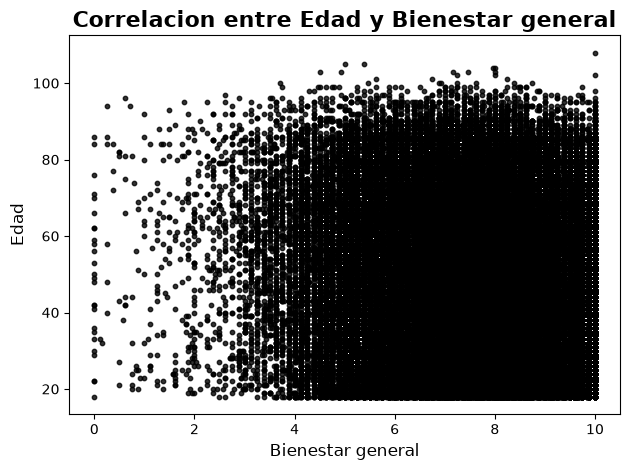

In [26]:
df_scatter = df.copy()
df_scatter.plot.scatter(x="Bienestar_general",y="Edad", color="black",s=10, alpha=0.8,)
plt.title("Correlacion entre Edad y Bienestar general", fontsize=16, fontweight="bold")
plt.xlabel("Bienestar general", fontsize=12)
plt.ylabel("Edad", fontsize=12)
plt.tight_layout()
plt.show()

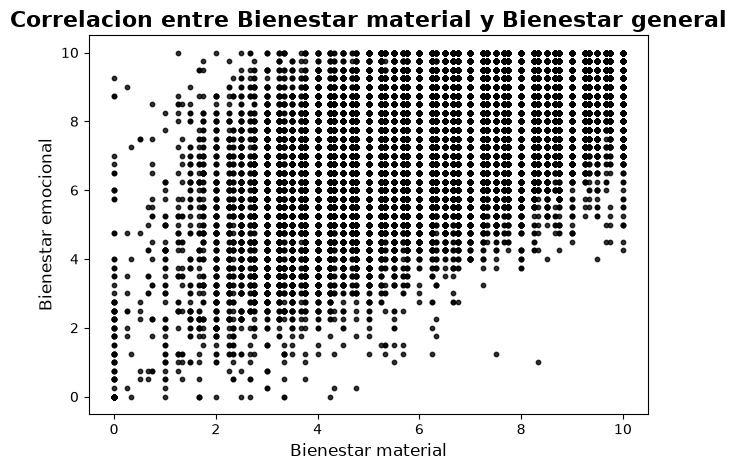

In [27]:
df_scatter_material_emocional = df.copy()
df_scatter_material_emocional.plot.scatter(x="Bienestar_material",y="Bienestar_emocional", color="black",s=10, alpha=0.8,)
plt.title("Correlacion entre Bienestar material y Bienestar general", fontsize=16, fontweight="bold")
plt.xlabel("Bienestar material", fontsize=12)
plt.ylabel("Bienestar emocional", fontsize=12)
plt.tight_layout()
plt.show()